# ProstT5 Folding HMM Drafter — AA -> 3Di

This notebook implements a focused folding-direction drafter for `AA -> 3Di`.
It reuses the style of `prostT5_speculative_decoding_hf.ipynb`, but only implements the HMM-based folding experiment.

The HMM drafter is now protein-family-specific:

- for each target protein, the notebook queries the ColabFold/MMseqs2 API for an AA family MSA;
- homolog AA rows are folded once with ProstT5 to create cached pseudo-3Di labels;
- those pseudo-labels are projected back onto the query-aligned MSA columns;
- static and prefix-aware draft distributions are estimated only from that target protein's MSA family.

This avoids training one global AA/3Di HMM across unrelated benchmark proteins. If the API/cache has no usable homolog rows for a protein, the drafter falls back to a uniform distribution for that protein rather than borrowing another family.


## Setup

Install/import dependencies, choose the runtime device, and fix random seeds for reproducible stochastic behavior.


### What this cell does

Sets up the notebook runtime.

- Imports Python, PyTorch, Transformers, plotting/data packages, and helper libraries.
- Fixes the random seed for reproducibility.
- Selects the runtime device.
- Requires CUDA/GPU, because this folding benchmark is intended for Colab GPU.


In [1]:
#@title Imports + seed. { display-mode: "form" }

import os, sys, time, statistics, json, importlib.util, subprocess, io, tarfile, zipfile, gc
from pathlib import Path
from collections import defaultdict

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Colab often misses these two packages. Install only when needed.
def _ensure_package(import_name: str, pip_name: str | None = None):
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

_ensure_package("sentencepiece")
_ensure_package("accelerate")
_ensure_package("requests")

import numpy as np
import pandas as pd
import torch
import requests
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM, GenerationConfig, PreTrainedModel, T5Config
from transformers.generation.utils import GenerationMixin
from transformers.modeling_outputs import Seq2SeqLMOutput

SEED = 0
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

REQUIRE_CUDA_RUNTIME = True
print(f"torch={torch.__version__}  device={device}  seed={SEED}")
if REQUIRE_CUDA_RUNTIME and device.type != "cuda":
    raise RuntimeError(
        "This notebook is configured for Colab GPU/CUDA. "
        "In Colab, switch Runtime -> Change runtime type -> GPU, then rerun."
    )
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True


torch=2.11.0+cu128  device=cuda:0  seed=0


##### The testing Protein is defined here, change to benchmark when evaluating.

- EMBEDDED_AA_FASTA
- EMBEDDED_3DI_FASTA

### What this cell does

Provides a small local fallback dataset for notebook smoke tests.

- Writes embedded AA and 3Di FASTA files only if the benchmark files are missing.
- Keeps the notebook runnable in Colab after upload or clone.
- Does not change the main benchmark data when the real files exist.


In [2]:
#@title Colab local data setup. { display-mode: "form" }

# No Drive and no manual data copy needed.
# In Colab this cell writes a tiny 10-protein benchmark subset into /content.
# The subset uses the 10 shortest paired AA/3Di examples to keep smoke runs light.

from pathlib import Path

EMBEDDED_AA_FASTA = '>P01542\nTTCCPSIVARSNFNVCRLPGTPEALCATYTGCIIIPGATCPGDYAN\n>P0A7N4\nMAVQQNKPTRSKRGMRRSHDALTAVTSLSVDKTSGEKHLRHHITADGYYRGRKVIAK\n>P02798\nMDPNCSCASDGSCSCAGACKCKQCKCTSCKKSCCSCCPVGCAKCSQGCICKEASDKCSCCA\n>P61583\nMNPSEMQRKGPPQRWCLQVYPTAPKRQRPSRTGHDDDGGFVEKKRGKCGEKQERSDCYCVCVERSRHRRLHFVLY\n>P24311\nMFPLVKSALNRLQVRSIQQTMARQSHQKRTPDFHDKYGNAVLASGATFCIVTWTYVATQVGIEWNLSPVGRVTPKEWRNQ\n>P0A7U3\nMPRSLKKGPFIDLHLLKKVEKAVESGDKKPLRTWSRRSTIFPNMIGLTIAVHNGRQHVPVFVTDEMVGHKLGEFAPTRTY\nRGHAADKKAKKK\n>P63165\nMSDQEAKPSTEDLGDKKEGEYIKLKVIGQDSSEIHFKVKMTTHLKKLKESYCQRQGVPMNSLRFLFEGQRIADNHTPKEL\nGMEEEDVIEVYQEQTGGHSTV\n>P10599\nMVKQIESKTAFQEALDAAGDKLVVVDFSATWCGPCKMIKPFFHSLSEKYSNVIFLEVDVDDCQDVASECEVKCMPTFQFF\nKKGQKVGEFSGANKEKLEATINELV\n>P01308\nMALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPL\nALEGSLQKRGIVEQCCTSICSLYQLENYCN\n>P61769\nMSRSVALAVLALLSLSGLEAIQRTPKIQVYSRHPAENGKSNFLNCYVSGFHPSDIEVDLLKNGERIEKVEHSDLSFSKDW\nSFYLLYYTEFTPTEKDEYACRVNHVTLSQPKIVKWDRDM\n'
EMBEDDED_3DI_FASTA = '>P01542\ndkfaqdpvlvvqlvvcppvvpdsvvscvvsvidddpdddddpsrhd\n>P0A7N4\nddddpddddpvrvcvvcppvddddlpqwdaapqprdidgvpdadpcqddnndrnddd\n>P02798\ndppqfpadpplpdqclqvtnglddprpsrqddnaladdrpqvvcpvhdpdpdrdnhdpvrd\n>P61583\nddpvvvppdddqpwfkfwdaddddppddpddpdpdpppddgdrdrddpddddpdhrifiwtwgcdpvndtdtdgd\n>P24311\ndvvvvvvvvvvvvvvvvvvvvvvvvvpppdqdpcsvcvvvcvvvvvvvvvvvvvcvvppppddpvddcvvppdddppddd\n>P0A7U3\ndaddpvvdfdddpvqvvvlvvclvvvdqdaaedqqqrhfdapscaqhwyqydlppggdtdhdhpvrggpgnnvvrhnddd\npddpppppdddd\n>P63165\nddddddddddddpddddppfwaweweaepvrdtdididgqqdfclvvlvvvcvvvvhdsvqkfkdfpndtgdrrdgcnvv\nvhhhhgyiyidgppppdpppd\n>P10599\ndeaedqepvsvvvvlqvlaqakekewaaappdpqqvvqvvvlvvvcvvcvsyyhyyydcvryvvvcvvvvpddpgkmfmd\ngssdtpdidhtndsvvvvvvvvvsd\n>P01308\ndvpvvvvvvvvvcccvvpdpppppddddddpddppvvvvvcvlvppddppdpdddddddddddddddddddddddddddd\ndpppppppddpppvpsvdpddpvvvvvpsd\n>P61769\ndppvvvvvvvvvvvvvvppddfwdwdwdwewpdqadaqdktkikikiwggpdpdkdkfkdkpndgdppkdkdpwdhdpvr\niiimmimdmdgddppikiwmwmddpvdpdididtydsvd\n'

def _write_text_if_needed(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists() or path.read_text() != text:
        path.write_text(text)
    print(f"{path}  {path.stat().st_size} bytes")

LOCAL_PROJECT_DIR = Path("/content/Speculative-Decoding-ProstT5")
LOCAL_DATA_DIR = LOCAL_PROJECT_DIR / "prostT5" / "prostT5_benchmarks" / "benchmark_data"

if Path("/content").exists():
    _write_text_if_needed(LOCAL_DATA_DIR / "test_set_AA.fasta", EMBEDDED_AA_FASTA)
    _write_text_if_needed(LOCAL_DATA_DIR / "test_set_3Di.fasta", EMBEDDED_3DI_FASTA)
    print(f"Local Colab data ready: {LOCAL_DATA_DIR}")
else:
    print("Not in Colab; using local repository data if present.")


/content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta  941 bytes
/content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_3Di.fasta  941 bytes
Local Colab data ready: /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data


## Configuration

Define model paths, benchmark paths, and benchmark settings. This notebook uses the same benchmark FASTA files as the inverse-folding experiments.


### What this cell does

Defines the main experiment settings.

Key parameters:

- `K_VALUES`: draft lengths tested during assisted generation.
- `BENCHMARK_PROTEIN_LIMIT`: number of paired proteins used in the benchmark.
- `RUN_BENCHMARKS`: whether Part 2 timing benchmarks should run.
- `FAMILY_MSA_MAX_SEQS`: maximum homolog rows used per family drafter.
- `FAMILY_GENERALIZATION_TRAIN_SEQS`: number of homologs used for the Part 1 mini family test.
- `FAMILY_GENERALIZATION_HOLDOUT_PER_FAMILY`: number of held-out homologs per family in Part 1.


In [3]:
#@title Configuration. { display-mode: "form" }

PROSTT5_NAME = "Rostlab/ProstT5_fp16"
NOTEBOOK_DIR = Path.cwd().resolve()

def _find_prost_dir(start: Path) -> Path:
    """Find the prostT5 project folder locally or inside a mounted Colab Drive."""
    candidates = []
    candidates.extend([start, *start.parents])
    candidates.extend([
        Path("/content/Speculative-Decoding-ProstT5"),
        Path("/content/drive/MyDrive/Speculative-Decoding-ProstT5"),
        Path("/content/drive/MyDrive/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5"),
    ])

    for base in candidates:
        for cand in (base, base / "prostT5"):
            if (cand / "prostT5_benchmarks" / "benchmark_data" / "test_set_AA.fasta").exists():
                return cand.resolve()

    for root in (Path("/content/Speculative-Decoding-ProstT5"), Path("/content"), Path("/content/drive/MyDrive")):
        if root.exists():
            for aa_path in root.glob("**/prostT5_benchmarks/benchmark_data/test_set_AA.fasta"):
                return aa_path.parents[2].resolve()

    raise FileNotFoundError(
        "Could not find prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta. "
        "In Colab, mount Drive or cd into the cloned Speculative-Decoding-ProstT5 repo first."
    )

PROST_DIR = _find_prost_dir(NOTEBOOK_DIR)
DATA_DIR = PROST_DIR / "prostT5_benchmarks" / "benchmark_data"
RESULTS_DIR = PROST_DIR / "results" / "folding_hmm_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_AA_FASTA = DATA_DIR / "test_set_AA.fasta"
TEST_3DI_FASTA = DATA_DIR / "test_set_3Di.fasta"

USE_FP16 = True
NUM_WARMUP = 0
NUM_REPEATS = 1
K_VALUES = [1, 3, 5, 8, 11, 15, 20]
HELD_OUT_N = 2
MAX_CONTEXT_P = 5
BENCHMARK_PROTEIN_LIMIT = 10
RUN_BENCHMARKS = True
FAMILY_MSA_MODE = "env"
FAMILY_MSA_MAX_SEQS = 64
FAMILY_MSA_MIN_SEQ_LEN = 40
FAMILY_API_DELAY_S = 2.0

RUN_FAMILY_GENERALIZATION = True
FAMILY_GENERALIZATION_SEED_IDS = ["P01542", "P0A7N4"]
FAMILY_GENERALIZATION_TRAIN_SEQS = 32
FAMILY_GENERALIZATION_MAX_SEQS = 64
FAMILY_GENERALIZATION_HOLDOUT_PER_FAMILY = 2

AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
HMM_SMOOTHING = 0.5

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Project dir : {PROST_DIR}")
print(f"AA FASTA    : {TEST_AA_FASTA}")
print(f"3Di FASTA   : {TEST_3DI_FASTA}")
print(f"Protein limit: {BENCHMARK_PROTEIN_LIMIT}")
print(f"K values    : {K_VALUES}")
print(f"Family MSA max homologs: {FAMILY_MSA_MAX_SEQS}")
print(f"Family generalization train size: {FAMILY_GENERALIZATION_TRAIN_SEQS}")
assert TEST_AA_FASTA.exists(), TEST_AA_FASTA
assert TEST_3DI_FASTA.exists(), TEST_3DI_FASTA


Notebook dir: /content
Project dir : /content/Speculative-Decoding-ProstT5/prostT5
AA FASTA    : /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta
3Di FASTA   : /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_3Di.fasta
Protein limit: 10
K values    : [1, 3, 5, 8]
Family MSA max homologs: 16
Family generalization train size: 32


## Load ProstT5

Load the same full ProstT5 encoder-decoder model, but use the folding prompt `<AA2fold>` so the model generates 3Di tokens from AA input.


### What this cell does

Loads the ProstT5 verifier model for AA to 3Di folding.

- Uses `Rostlab/ProstT5_fp16`.
- Loads directly onto CUDA with `device_map` to avoid an extra CPU copy.
- Disables generation cache to reduce memory pressure during repeated homolog folding and benchmarking.
- The model is the reference/verifier for correctness and timing.


In [4]:
#@title Load ProstT5. { display-mode: "form" }

try:
    tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)
except ImportError as exc:
    raise ImportError("T5Tokenizer needs sentencepiece. In Colab run: !pip -q install sentencepiece") from exc

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32


def _load_prostt5(**kwargs):
    try:
        return AutoModelForSeq2SeqLM.from_pretrained(PROSTT5_NAME, dtype=dtype, **kwargs)
    except TypeError:
        # Older transformers versions use torch_dtype instead of dtype.
        return AutoModelForSeq2SeqLM.from_pretrained(PROSTT5_NAME, torch_dtype=dtype, **kwargs)


# This notebook is GPU-only by design. Use device_map on CUDA to avoid an
# unnecessary full CPU copy during model load.
model = _load_prostt5(low_cpu_mem_usage=True, device_map={"": str(device)})
model.eval()
model.config.use_cache = False
model.generation_config.use_cache = False

encoder = model.get_encoder()
DECODER_START_TOKEN_ID = model.config.decoder_start_token_id

print(f"ProstT5 loaded. dtype={dtype} params={sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Decoder start token ID: {DECODER_START_TOKEN_ID}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

ProstT5 loaded. dtype=torch.float16 params=2818.9M
Decoder start token ID: 0


## Load Paired Benchmark FASTA

Parse AA and 3Di FASTA files, match records by UniProt ID, and keep only proteins where AA and 3Di lengths match.


### What this cell does

Loads and pairs the benchmark AA and 3Di sequences.

- Parses `test_set_AA.fasta` and `test_set_3Di.fasta`.
- Matches records by protein ID.
- Keeps only proteins where AA length and 3Di length agree.
- Stores valid pairs in `paired`.


In [5]:
#@title FASTA parsing + paired dataset. { display-mode: "form" }

def parse_fasta(path: Path) -> dict[str, str]:
    records = {}
    cur = None
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                cur = line[1:].split()[0]
                records[cur] = ""
            else:
                records[cur] += line.strip()
    return records

AA_SEQS = parse_fasta(TEST_AA_FASTA)
DI_SEQS = {uid: seq.lower() for uid, seq in parse_fasta(TEST_3DI_FASTA).items()}

paired = {}
for uid in sorted(set(AA_SEQS) & set(DI_SEQS)):
    aa = AA_SEQS[uid].upper()
    di = DI_SEQS[uid].lower()
    if len(aa) != len(di):
        print(f"skip {uid}: length mismatch AA={len(aa)} 3Di={len(di)}")
        continue
    paired[uid] = {"aa": aa, "3di": di, "length": len(aa)}

print(f"Loaded paired benchmark records: {len(paired)}")
print("First records:")
for uid, rec in list(paired.items())[:2]:
    print(f"  {uid}: L={rec['length']} AA={rec['aa'][:12]} 3Di={rec['3di'][:12]}")


Loaded paired benchmark records: 10
First records:
  P01308: L=110 AA=MALWMRLLPLLA 3Di=dvpvvvvvvvvv
  P01542: L=46 AA=TTCCPSIVARSN 3Di=dkfaqdpvlvvq


## Tokenization Helpers

ProstT5 uses task prefixes. For folding we use `<AA2fold>` and generate lowercase 3Di tokens.


### What this cell does

Defines tokenization helpers for the folding direction.

Important objects:

- `_format_aa(seq)`: formats AA input with the `<AA2fold>` task prefix.
- `_decode_3di(token_ids)`: decodes model output back into a compact 3Di string.
- `THREEDI_TOKEN_IDS`: maps each 3Di symbol to its ProstT5 tokenizer ID.

`THREEDI_TOKEN_IDS` is the bridge from the drafter's 20-token 3Di distribution into the full ProstT5 vocabulary.


In [6]:
#@title Folding format helpers. { display-mode: "form" }

def _format_aa(seq: str) -> str:
    return "<AA2fold> " + " ".join(list(seq.upper()))


def _decode_3di(token_ids: torch.Tensor) -> str:
    if token_ids.ndim > 1:
        token_ids = token_ids[0]
    s = tokenizer.decode(token_ids, skip_special_tokens=True)
    return "".join(s.split()).replace("<AA2fold>", "").lower()

THREEDI_ALPHABET = "".join(sorted(set("".join(rec["3di"] for rec in paired.values()))))
THREEDI_TOKEN_IDS = [tokenizer.encode(f" {tok}", add_special_tokens=False)[0] for tok in THREEDI_ALPHABET]
THREEDI_TOKEN_ID_TO_IDX = {tid: i for i, tid in enumerate(THREEDI_TOKEN_IDS)}
THREEDI_IDX_TO_TOKEN_ID = {i: tid for i, tid in enumerate(THREEDI_TOKEN_IDS)}
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_LETTERS)}

print(f"3Di alphabet ({len(THREEDI_ALPHABET)}): {THREEDI_ALPHABET}")
print("First 3Di token IDs:", list(zip(THREEDI_ALPHABET[:8], THREEDI_TOKEN_IDS[:8])))


3Di alphabet (20): acdefghiklmnpqrstvwy
First 3Di token IDs: [('a', 128), ('c', 147), ('d', 135), ('e', 134), ('f', 140), ('g', 130), ('h', 145), ('i', 137)]


## Reference Folding Generation

This is the plain ProstT5 `AA -> 3Di` greedy generation path. It is the verifier/reference output used for correctness checks.

#### Maybe we can cache it so we can reuse the 3Di

### What this cell does

Defines the plain ProstT5 folding reference path.

- Input: AA sequence.
- Output: greedy ProstT5 3Di sequence.
- This is the verifier/reference output used by correctness checks.
- Assisted generation should match this output in strict greedy speculative decoding.


In [7]:
#@title Plain enc-dec folding reference. { display-mode: "form" }

@torch.inference_mode()
def generate_folding_reference(aa_seq: str) -> str:
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = None
    try:
        out = model.generate(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
            max_length=L + 2,
            do_sample=False,
            num_beams=1,
            use_cache=False,
        )
        seq = _decode_3di(out[0])[:L]
        return seq
    finally:
        # Building family HMMs folds many homologs; release transient generate() tensors promptly.
        del enc
        if out is not None:
            del out
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        elif device.type == "mps" and hasattr(torch, "mps"):
            torch.mps.empty_cache()


## Family-Specific AA-Conditioned 3Di HMM

Build a per-protein drafter from that protein's MMseqs2/ColabFold AA family MSA. Because the API returns AA homologs rather than 3Di labels, the notebook folds a capped number of homolog rows once with ProstT5, projects those pseudo-3Di labels back to query-aligned MSA columns, and estimates draft distributions only from that target family's projected rows.


### What this cell does

Builds the family-specific folding drafter machinery.

Flow:

- Fetch or load an A3M MSA for the query protein.
- Select homolog AA rows from that family.
- Fold homolog AA rows with ProstT5 to obtain pseudo-3Di labels.
- Project pseudo-3Di labels back onto query-aligned MSA columns.
- Count per-position 3Di tokens and convert them into draft logits.

This is not a true Profile HMM over 3Di states. It is a family-local pseudo-3Di drafter.


In [8]:
#@title Family-specific AA-conditioned 3Di HMM from MMseqs2 MSA. { display-mode: "form" }

COLABFOLD_HOST = "https://api.colabfold.com"
COLABFOLD_HEADERS = {
    "User-Agent": "prostt5-folding-hmm-family-notebook/1.0 (educational use)"
}
COLABFOLD_RETRY_STATUS = {429, 500, 502, 503, 504}
THREEDI_SYMBOL_TO_IDX = {tok: i for i, tok in enumerate(THREEDI_ALPHABET)}


def _log_normalize(x: np.ndarray, axis=None) -> np.ndarray:
    m = np.max(x, axis=axis, keepdims=True)
    return x - (m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True)))


def _cf_request(method: str, url: str, *, max_retries: int = 8,
                base_backoff: float = 10.0, max_backoff: float = 120.0,
                **kwargs) -> requests.Response:
    """ColabFold API request with quiet exponential backoff."""
    kwargs.setdefault("headers", COLABFOLD_HEADERS)
    resp = None
    for attempt in range(max_retries):
        resp = requests.request(method, url, **kwargs)
        if resp.status_code not in COLABFOLD_RETRY_STATUS:
            resp.raise_for_status()
            return resp
        retry_after = resp.headers.get("Retry-After")
        try:
            wait = float(retry_after) if retry_after is not None else None
        except ValueError:
            wait = None
        if wait is None:
            wait = min(base_backoff * (2 ** attempt), max_backoff)
        time.sleep(wait)
    resp.raise_for_status()
    return resp


def _fetch_msa_colabfold(aa_seq: str, cache_path: Path,
                         mode: str = FAMILY_MSA_MODE,
                         poll_interval: float = 5.0,
                         max_wait_s: float = 600.0) -> str | None:
    """Fetch/cache an A3M MSA for one protein family using the ColabFold MMseqs2 API."""
    if cache_path.exists():
        return cache_path.read_text()

    try:
        submit_attempts = 0
        while True:
            resp = _cf_request(
                "POST",
                f"{COLABFOLD_HOST}/ticket/msa",
                data={"q": f">query\n{aa_seq}\n", "mode": mode},
                timeout=30,
            )
            sub = resp.json()
            status = sub.get("status", "")
            if status != "RATELIMIT":
                break
            submit_attempts += 1
            if submit_attempts > 8:
                print("    MSA API rate-limited after retries; using uniform drafter")
                return None
            time.sleep(min(10.0 * (2 ** (submit_attempts - 1)), 120.0))

        job_id = sub.get("id")
        if not job_id:
            print("    MSA API returned no job id; using uniform drafter")
            return None

        waited = 0.0
        while status != "COMPLETE":
            if status in ("ERROR", "MAINTENANCE"):
                print(f"    MSA API status={status}; using uniform drafter")
                return None
            if waited >= max_wait_s:
                print("    MSA API timed out; using uniform drafter")
                return None
            time.sleep(poll_interval)
            waited += poll_interval
            sr = _cf_request("GET", f"{COLABFOLD_HOST}/ticket/{job_id}", timeout=15)
            status = sr.json().get("status", "")

        dl = _cf_request("GET", f"{COLABFOLD_HOST}/result/download/{job_id}", timeout=120)
        data = dl.content
        a3m_parts = []
        if data[:2] == b"PK":
            with zipfile.ZipFile(io.BytesIO(data)) as zf:
                for name in zf.namelist():
                    if name.endswith(".a3m"):
                        a3m_parts.append(zf.read(name).decode("utf-8", "ignore"))
        elif data[:2] == b"\x1f\x8b":
            with tarfile.open(fileobj=io.BytesIO(data)) as tf:
                for member in tf.getmembers():
                    if member.name.endswith(".a3m"):
                        fh = tf.extractfile(member)
                        if fh is not None:
                            a3m_parts.append(fh.read().decode("utf-8", "ignore"))
        else:
            txt = data.decode("utf-8", "ignore")
            if txt.lstrip().startswith(">"):
                a3m_parts.append(txt)

        a3m_text = "\n".join(part.strip() for part in a3m_parts if part.strip()) or None
        if a3m_text is None:
            print("    MSA API result had no A3M; using uniform drafter")
            return None
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_text(a3m_text)
        return a3m_text
    except Exception as exc:
        print(f"    MSA fetch failed ({type(exc).__name__}); using uniform drafter")
        return None


def _parse_a3m_records(a3m: str) -> list[tuple[str, str]]:
    records = []
    name = None
    chunks = []
    for raw in a3m.splitlines():
        line = raw.replace("\x00", "").strip()
        if not line:
            continue
        if line.startswith(">"):
            if name is not None:
                records.append((name, "".join(chunks)))
            name = line[1:].split()[0] or f"seq{len(records)}"
            chunks = []
        else:
            chunks.append(line)
    if name is not None:
        records.append((name, "".join(chunks)))
    return records


def _strip_a3m_insertions(seq: str) -> str:
    return "".join(c.upper() for c in seq if not c.islower() and c not in ".*")


def _ungap_aa(seq: str) -> str:
    return "".join(c for c in seq.upper() if c in AA_TO_IDX)


def _project_homolog_3di_to_query(query_aln: str, homolog_aln: str, homolog_3di: str) -> list[str | None]:
    L = sum(1 for c in query_aln if c != "-")
    projected = [None] * L
    q_pos = 0
    h_pos = 0
    width = min(len(query_aln), len(homolog_aln))
    for i in range(width):
        q_char = query_aln[i]
        h_char = homolog_aln[i]
        h_token = None
        if h_char != "-":
            if h_pos < len(homolog_3di):
                h_token = homolog_3di[h_pos]
            h_pos += 1
        if q_char != "-":
            if h_token in THREEDI_SYMBOL_TO_IDX:
                projected[q_pos] = h_token
            q_pos += 1
    return projected


class FamilyFoldingHMMDrafter:
    """Protein-family-specific AA->3Di drafter built from one target's MSA family.

    The ColabFold API supplies only AA homologs. To keep the drafter family-local,
    homolog AA rows are folded once with ProstT5, projected to query MSA columns,
    and counted as pseudo-labeled family examples. No unrelated benchmark proteins
    are used for this target's HMM.
    """

    def __init__(self, uid: str, aa_seq: str, a3m: str | None,
                 max_family_seqs: int = FAMILY_MSA_MAX_SEQS,
                 smoothing: float = HMM_SMOOTHING):
        self.uid = uid
        self.aa_seq = aa_seq
        self.smoothing = smoothing
        self.max_family_seqs = max_family_seqs
        self.n_family_seqs = 0
        self.n_projected_seqs = 0
        self.context_counts = defaultdict(lambda: np.zeros(len(THREEDI_ALPHABET), dtype=np.float32))
        self.logits = self._build_logits(a3m)

    def _candidate_family_rows(self, a3m: str | None) -> list[tuple[str, str, str]]:
        if not a3m:
            return []
        records = _parse_a3m_records(a3m)
        if len(records) < 2:
            return []
        query_aln = _strip_a3m_insertions(records[0][1])
        rows = []
        seen = set()
        for name, raw_aln in records[1:]:
            aln = _strip_a3m_insertions(raw_aln)
            aa = _ungap_aa(aln)
            if len(aa) < FAMILY_MSA_MIN_SEQ_LEN or aa in seen:
                continue
            seen.add(aa)
            rows.append((name, query_aln, aln))
            if len(rows) >= self.max_family_seqs:
                break
        return rows

    def _build_logits(self, a3m: str | None) -> np.ndarray:
        L = len(self.aa_seq)
        S = len(THREEDI_ALPHABET)
        counts = np.full((L, S), self.smoothing, dtype=np.float32)
        rows = self._candidate_family_rows(a3m)
        self.n_family_seqs = len(rows)

        for _, query_aln, homolog_aln in rows:
            homolog_aa = _ungap_aa(homolog_aln)
            if not homolog_aa:
                continue
            homolog_3di = generate_folding_reference(homolog_aa)
            projected = _project_homolog_3di_to_query(query_aln, homolog_aln, homolog_3di)
            if len(projected) != L:
                continue
            observed = [(pos, tok) for pos, tok in enumerate(projected) if tok in THREEDI_SYMBOL_TO_IDX]
            if not observed:
                continue
            self.n_projected_seqs += 1
            for pos, tok in observed:
                counts[pos, THREEDI_SYMBOL_TO_IDX[tok]] += np.float32(1.0)
            for pos, tok in observed:
                for ctx_len in range(min(MAX_CONTEXT_P, pos), -1, -1):
                    ctx_start = pos - ctx_len
                    ctx = projected[ctx_start:pos]
                    if any(c not in THREEDI_SYMBOL_TO_IDX for c in ctx):
                        continue
                    self.context_counts[(pos, tuple(ctx))][THREEDI_SYMBOL_TO_IDX[tok]] += np.float32(1.0)

        return np.log(counts / counts.sum(axis=1, keepdims=True)).astype(np.float32)

    def get_draft_logits(self, pos: int, prefix=None, K: int | None = None):
        if pos >= self.logits.shape[0]:
            return self.logits[:0]
        if K is None:
            return self.logits[pos:]
        return self.logits[pos:pos + K]

    def emission_for_prefix(self, prefix_symbols: list[str], max_p: int) -> np.ndarray:
        pos = len(prefix_symbols)
        if pos >= self.logits.shape[0]:
            return np.full(len(THREEDI_ALPHABET), -np.log(len(THREEDI_ALPHABET)), dtype=np.float32)
        available = min(max_p, len(prefix_symbols))
        for ctx_len in range(available, -1, -1):
            ctx = tuple(prefix_symbols[-ctx_len:]) if ctx_len > 0 else tuple()
            key = (pos, ctx)
            if key in self.context_counts:
                counts = self.context_counts[key] + self.smoothing
                return np.log(counts / counts.sum()).astype(np.float32)
        return self.logits[pos]


class PrefixAwareFoldingHMMDrafter:
    """Prefix-aware view over a family-specific folding HMM drafter."""

    def __init__(self, base_drafter: FamilyFoldingHMMDrafter, max_p: int = 5):
        self.base_drafter = base_drafter
        self.uid = base_drafter.uid
        self.aa_seq = base_drafter.aa_seq
        self.max_p = max_p
        self.n_family_seqs = base_drafter.n_family_seqs
        self.n_projected_seqs = base_drafter.n_projected_seqs

    def emission_for_prefix(self, prefix_symbols: list[str]) -> np.ndarray:
        return self.base_drafter.emission_for_prefix(prefix_symbols, self.max_p)


def build_family_folding_drafter(uid: str, aa_seq: str, msa_dir: Path) -> FamilyFoldingHMMDrafter:
    cache_path = msa_dir / f"{uid}.a3m"
    cache_hit = cache_path.exists()
    a3m = _fetch_msa_colabfold(aa_seq, cache_path=cache_path)
    if a3m is not None and not cache_hit and FAMILY_API_DELAY_S > 0:
        time.sleep(FAMILY_API_DELAY_S)
    return FamilyFoldingHMMDrafter(uid, aa_seq, a3m)

print("Family-specific folding HMM helpers loaded (MMseqs2 MSA -> pseudo-3Di family counts).")


Family-specific folding HMM helpers loaded (MMseqs2 MSA -> pseudo-3Di family counts).


## Part 1: Two-Family Generalization Check

Build two compact family-level AA->3Di HMMs. For each family, use 32 training homologs by default (configurable up to 64), hold out two new homologs that are not used for fitting, then score each held-out protein with both the in-family and out-family model.


### Part 1 Drafter Used

The Part 1 mini test does **not** use HuggingFace speculative decoding and does **not** use the static `FamilyFoldingHMMDrafter` assistant wrapper. It uses the lightweight `FamilyAA3DiHMM` model defined in the next helper cell.

This drafter is a length-general family HMM over pseudo-3Di states: it learns `start`, `transition`, and `emission` probabilities from ProstT5 pseudo-labeled homologs. For each held-out homolog, `infer_logits(aa_seq)` runs forward-backward and returns per-position log probabilities over 3Di tokens. The metrics `token_acc` and `mean_ref_logp` are computed from those logits against the held-out homolog's pseudo-3Di reference.


### What this cell does

Defines the Part 1 mini family-test model.

- `FamilyAA3DiHMM` is used only for the mini in-family/out-family test.
- It learns start, transition, and AA-emission probabilities from pseudo-labeled homologs.
- It runs forward-backward to score held-out homologs.
- It is not the HuggingFace assisted-generation drafter used in Part 2.


In [9]:
#@title Part 1 helpers: family split + length-general AA-conditioned HMM. { display-mode: "form" }

FAMILY_GENERALIZATION_DIR = RESULTS_DIR / "family_generalization"
FAMILY_GENERALIZATION_MSA_DIR = FAMILY_GENERALIZATION_DIR / "msa"
FAMILY_GENERALIZATION_LABEL_DIR = FAMILY_GENERALIZATION_DIR / "pseudo_labels"
FAMILY_GENERALIZATION_MSA_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_GENERALIZATION_LABEL_DIR.mkdir(parents=True, exist_ok=True)


def _select_family_seed_ids() -> list[str]:
    seeds = [uid for uid in FAMILY_GENERALIZATION_SEED_IDS if uid in paired]
    if len(seeds) < 2:
        fallback = [uid for uid, _ in sorted(paired.items(), key=lambda kv: kv[1]["length"]) if uid not in seeds]
        seeds.extend(fallback[:2 - len(seeds)])
    return seeds[:2]


def _family_candidate_rows(seed_uid: str, aa_seq: str) -> list[dict]:
    cache_path = FAMILY_GENERALIZATION_MSA_DIR / f"{seed_uid}.a3m"
    cache_hit = cache_path.exists()
    a3m = _fetch_msa_colabfold(aa_seq, cache_path=cache_path)
    if a3m is not None and not cache_hit and FAMILY_API_DELAY_S > 0:
        time.sleep(FAMILY_API_DELAY_S)
    records = _parse_a3m_records(a3m) if a3m else []
    rows = []
    seen = {aa_seq.upper()}
    need = FAMILY_GENERALIZATION_MAX_SEQS + FAMILY_GENERALIZATION_HOLDOUT_PER_FAMILY
    for name, raw_aln in records[1:]:
        aa = _ungap_aa(_strip_a3m_insertions(raw_aln))
        if len(aa) < FAMILY_MSA_MIN_SEQ_LEN or aa in seen:
            continue
        seen.add(aa)
        rows.append({"member_id": name, "aa": aa})
        if len(rows) >= need:
            break
    return rows


def _load_or_fold_family_examples(seed_uid: str, rows: list[dict]) -> list[dict]:
    cache_path = FAMILY_GENERALIZATION_LABEL_DIR / f"{seed_uid}.json"
    cached = []
    if cache_path.exists():
        cached = json.loads(cache_path.read_text())
    by_aa = {ex["aa"]: ex for ex in cached if "aa" in ex and "3di" in ex}
    examples = []
    for i, row in enumerate(rows, start=1):
        aa = row["aa"]
        if aa not in by_aa:
            di = generate_folding_reference(aa)
            by_aa[aa] = {"member_id": row["member_id"], "aa": aa, "3di": di}
            cache_path.write_text(json.dumps(list(by_aa.values()), indent=2))
        examples.append(by_aa[aa])
        if device.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        elif device.type == "mps" and hasattr(torch, "mps"):
            torch.mps.empty_cache()
        if i % 8 == 0 or i == len(rows):
            print(f"    {seed_uid}: pseudo-folded/cached {i}/{len(rows)} family rows")
    return examples


class FamilyAA3DiHMM:
    """Length-general family model: hidden state is 3Di, observation is AA."""

    def __init__(self, train_examples: list[dict], smoothing: float = HMM_SMOOTHING):
        self.train_examples = train_examples
        self.smoothing = smoothing
        self.n_states = len(THREEDI_ALPHABET)
        self.n_obs = len(AA_LETTERS)
        self.di_to_idx = THREEDI_SYMBOL_TO_IDX
        self.aa_to_idx = AA_TO_IDX
        self._fit()

    def _fit(self):
        start = np.full(self.n_states, self.smoothing, dtype=np.float32)
        trans = np.full((self.n_states, self.n_states), self.smoothing, dtype=np.float32)
        emit = np.full((self.n_states, self.n_obs), self.smoothing, dtype=np.float32)
        usable = 0
        for ex in self.train_examples:
            aa = ex["aa"].upper()
            di = ex["3di"].lower()
            if len(aa) != len(di):
                continue
            prev = None
            n_obs = 0
            for pos, (aa_tok, di_tok) in enumerate(zip(aa, di)):
                if aa_tok not in self.aa_to_idx or di_tok not in self.di_to_idx:
                    continue
                z = self.di_to_idx[di_tok]
                x = self.aa_to_idx[aa_tok]
                emit[z, x] += np.float32(1.0)
                if pos == 0:
                    start[z] += np.float32(1.0)
                if prev is not None:
                    trans[prev, z] += np.float32(1.0)
                prev = z
                n_obs += 1
            usable += int(n_obs > 0)
        self.n_train = usable
        self.log_start = np.log(start / start.sum()).astype(np.float32)
        self.log_trans = np.log(trans / trans.sum(axis=1, keepdims=True)).astype(np.float32)
        self.log_emit = np.log(emit / emit.sum(axis=1, keepdims=True)).astype(np.float32)

    def infer_logits(self, aa_seq: str) -> np.ndarray:
        obs = [self.aa_to_idx.get(a) for a in aa_seq.upper()]
        L = len(obs)
        S = self.n_states
        if L == 0:
            return np.zeros((0, S), dtype=np.float32)
        emit_by_pos = np.empty((L, S), dtype=np.float32)
        uniform_emit = np.float32(-np.log(self.n_obs))
        for t, x in enumerate(obs):
            emit_by_pos[t] = self.log_emit[:, x] if x is not None else uniform_emit
        alpha = np.full((L, S), -np.inf, dtype=np.float32)
        beta = np.full((L, S), -np.inf, dtype=np.float32)
        alpha[0] = self.log_start + emit_by_pos[0]
        for t in range(1, L):
            alpha[t] = emit_by_pos[t] + np.logaddexp.reduce(alpha[t - 1][:, None] + self.log_trans, axis=0)
        beta[-1] = 0.0
        for t in range(L - 2, -1, -1):
            beta[t] = np.logaddexp.reduce(self.log_trans + emit_by_pos[t + 1][None, :] + beta[t + 1][None, :], axis=1)
        posterior = alpha + beta - np.logaddexp.reduce(alpha[-1])
        return _log_normalize(posterior, axis=1).astype(np.float32)


def _score_family_model(model_obj: FamilyAA3DiHMM, test_ex: dict) -> dict:
    logits = model_obj.infer_logits(test_ex["aa"])
    ref = test_ex["3di"].lower()
    L = min(len(ref), logits.shape[0])
    if L == 0:
        return {"token_acc": float("nan"), "mean_ref_logp": float("nan")}
    ref_idx = np.array([THREEDI_SYMBOL_TO_IDX.get(tok, -1) for tok in ref[:L]])
    valid = ref_idx >= 0
    pred_idx = logits[:L].argmax(axis=1)
    token_acc = float((pred_idx[valid] == ref_idx[valid]).mean()) if valid.any() else float("nan")
    mean_ref_logp = float(logits[np.arange(L)[valid], ref_idx[valid]].mean()) if valid.any() else float("nan")
    return {"token_acc": token_acc, "mean_ref_logp": mean_ref_logp}


print("Part 1 helpers loaded: family split + AA-conditioned HMM.")


Part 1 helpers loaded: family split + AA-conditioned HMM.


## Part 1 Run: In-Family vs Cross-Family


### What this cell does

Runs the Part 1 family-generalization sanity check.

Settings:

- Seed families: `P01542` and `P0A7N4`.
- Training homologs per family: `FAMILY_GENERALIZATION_TRAIN_SEQS`.
- Held-out homologs per family: `FAMILY_GENERALIZATION_HOLDOUT_PER_FAMILY`.

Each held-out homolog is scored by its own family model and by the other family model.


In [10]:
#@title Run the two-family in-family / out-family check. { display-mode: "form" }

if not RUN_FAMILY_GENERALIZATION:
    print("Skipping family generalization check (RUN_FAMILY_GENERALIZATION=False).")
    family_generalization_df = pd.DataFrame()
else:
    seed_ids = _select_family_seed_ids()
    train_n = int(np.clip(FAMILY_GENERALIZATION_TRAIN_SEQS, 32, FAMILY_GENERALIZATION_MAX_SEQS))
    holdout_n = FAMILY_GENERALIZATION_HOLDOUT_PER_FAMILY
    family_models = {}
    family_holdouts = {}
    family_summary = []

    print(f"Building {len(seed_ids)} family models with {train_n} training homologs and {holdout_n} held-out homologs each.")
    for seed_uid in seed_ids:
        seed_aa = paired[seed_uid]["aa"]
        candidates = _family_candidate_rows(seed_uid, seed_aa)
        needed = train_n + holdout_n
        if len(candidates) < needed:
            print(f"  WARNING {seed_uid}: only {len(candidates)} homologs available, wanted {needed}.")
        selected = candidates[:needed]
        examples = _load_or_fold_family_examples(seed_uid, selected)
        holdouts = examples[:holdout_n]
        train = examples[holdout_n:holdout_n + train_n]
        family_models[seed_uid] = FamilyAA3DiHMM(train)
        family_holdouts[seed_uid] = holdouts
        family_summary.append({
            "family_id": seed_uid,
            "candidates": len(candidates),
            "train_examples": len(train),
            "heldout_examples": len(holdouts),
            "usable_train_examples": family_models[seed_uid].n_train,
        })
        print(
            f"  {seed_uid}: train={len(train)}, heldout={len(holdouts)}, "
            f"usable_train={family_models[seed_uid].n_train}"
        )

    rows = []
    for test_family, holdouts in family_holdouts.items():
        for h_idx, ex in enumerate(holdouts, start=1):
            for model_family, model_obj in family_models.items():
                score = _score_family_model(model_obj, ex)
                rows.append({
                    "test_family": test_family,
                    "model_family": model_family,
                    "relation": "in_family" if test_family == model_family else "out_family",
                    "heldout_index": h_idx,
                    "heldout_member_id": ex["member_id"],
                    "length": len(ex["aa"]),
                    "token_acc": score["token_acc"],
                    "mean_ref_logp": score["mean_ref_logp"],
                })

    family_generalization_df = pd.DataFrame(rows)
    family_summary_df = pd.DataFrame(family_summary)
    family_generalization_path = FAMILY_GENERALIZATION_DIR / "family_cross_test.csv"
    family_summary_path = FAMILY_GENERALIZATION_DIR / "family_build_summary.csv"
    family_generalization_df.to_csv(family_generalization_path, index=False)
    family_summary_df.to_csv(family_summary_path, index=False)

    print("Family build summary:")
    display(family_summary_df)
    print("In-family vs out-family heldout scores:")
    display(family_generalization_df)
    print("Mean by relation:")
    display(family_generalization_df.groupby("relation")[["token_acc", "mean_ref_logp"]].mean().reset_index())
    print(f"Saved family cross-test rows to {family_generalization_path}")


Building 2 family models with 32 training homologs and 2 held-out homologs each.
    P01542: pseudo-folded/cached 8/34 family rows
    P01542: pseudo-folded/cached 16/34 family rows
    P01542: pseudo-folded/cached 24/34 family rows
    P01542: pseudo-folded/cached 32/34 family rows
    P01542: pseudo-folded/cached 34/34 family rows
  P01542: train=32, heldout=2, usable_train=32
    P0A7N4: pseudo-folded/cached 8/34 family rows
    P0A7N4: pseudo-folded/cached 16/34 family rows
    P0A7N4: pseudo-folded/cached 24/34 family rows
    P0A7N4: pseudo-folded/cached 32/34 family rows
    P0A7N4: pseudo-folded/cached 34/34 family rows
  P0A7N4: train=32, heldout=2, usable_train=32
Family build summary:


,family_id,candidates,train_examples,heldout_examples,usable_train_examples
0,P01542,66,32,2,32
1,P0A7N4,66,32,2,32


In-family vs out-family heldout scores:


,test_family,model_family,relation,heldout_index,heldout_member_id,length,token_acc,mean_ref_logp
0,P01542,P01542,in_family,1,UniRef100_Q43227,44,0.681818,-1.219841
1,P01542,P0A7N4,out_family,1,UniRef100_Q43227,44,0.295455,-3.156592
2,P01542,P01542,in_family,2,UniRef100_UPI00053B8874,43,0.581395,-1.071089
3,P01542,P0A7N4,out_family,2,UniRef100_UPI00053B8874,43,0.279070,-3.258580
4,P0A7N4,P01542,out_family,1,UniRef100_A0A942JXP8,55,0.181818,-2.582995
5,P0A7N4,P0A7N4,in_family,1,UniRef100_A0A942JXP8,55,0.709091,-0.877575
6,P0A7N4,P01542,out_family,2,UniRef100_A0A7V5U4P8,56,0.375000,-2.309667
7,P0A7N4,P0A7N4,in_family,2,UniRef100_A0A7V5U4P8,56,0.660714,-0.938904


Mean by relation:


,relation,token_acc,mean_ref_logp
0,in_family,0.658255,-1.026852
1,out_family,0.282836,-2.826959


Saved family cross-test rows to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/family_generalization/family_cross_test.csv


## Part 2: Assisted-Generation Benchmark

After the small family cross-test above, build the per-target HMM assistant drafters and run the timing benchmark.


## Build Family HMM Drafters

Build one family-specific HMM drafter per benchmark protein. Each drafter uses only its own cached MSA family; if no usable homolog rows are available, it falls back to a uniform drafter for that protein.


### What this cell does

Builds the static Part 2 drafter for each benchmark protein.

- One `FamilyFoldingHMMDrafter` is built per query protein.
- Each drafter uses only that protein's MSA family.
- The drafter returns position-specific 3Di distributions.
- It does not look back at the generated prefix.


In [11]:
#@title Build family-specific folding HMM drafters. { display-mode: "form" }

FAMILY_MSA_DIR = RESULTS_DIR / "family_msa"
FAMILY_MSA_DIR.mkdir(parents=True, exist_ok=True)

hmm_drafters = {}
drafter_items = sorted(paired.items(), key=lambda kv: kv[1]["length"])
if BENCHMARK_PROTEIN_LIMIT is not None:
    drafter_items = drafter_items[:max(BENCHMARK_PROTEIN_LIMIT, HELD_OUT_N)]

print(f"Building family HMM drafters for {len(drafter_items)} proteins...")
for i, (uid, rec) in enumerate(drafter_items, start=1):
    d = build_family_folding_drafter(uid, rec["aa"], FAMILY_MSA_DIR)
    hmm_drafters[uid] = d
    print(f"  [{i}/{len(drafter_items)}] {uid}: homologs={d.n_family_seqs}, projected={d.n_projected_seqs}")
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()

n_family = sum(d.n_projected_seqs > 0 for d in hmm_drafters.values())
print(f"Family HMM coverage: {n_family}/{len(hmm_drafters)} with projected homolog pseudo-labels")


Building family HMM drafters for 10 proteins...
  [1/10] P01542: homologs=16, projected=16
  [2/10] P0A7N4: homologs=16, projected=16
  [3/10] P02798: homologs=16, projected=16
  [4/10] P61583: homologs=16, projected=16
  [5/10] P24311: homologs=16, projected=16
  [6/10] P0A7U3: homologs=16, projected=16
  [7/10] P63165: homologs=16, projected=16
  [8/10] P10599: homologs=16, projected=16
  [9/10] P01308: homologs=16, projected=16
  [10/10] P61769: homologs=16, projected=16
Family HMM coverage: 10/10 with projected homolog pseudo-labels


## Prefix-Aware Family HMM

The prefix-aware view reuses the same family-specific projected pseudo-3Di rows, but conditions the next-token distribution on previously accepted 3Di tokens up to context length `p`.


### What this cell does

Defines the prefix-aware view of the family drafter.

- Reuses the same family pseudo-3Di counts.
- Conditions on recent accepted 3Di prefix tokens.
- Falls back to the static position-wise distribution when a prefix context is missing.


In [12]:
#@title Prefix-aware context HMM for AA -> 3Di. { display-mode: "form" }

# PrefixAwareFoldingHMMDrafter is defined with the family-specific HMM helpers.
# It reuses each protein's MSA-derived pseudo-3Di family counts and conditions on
# the accepted 3Di prefix up to max_p tokens.
print("Prefix-aware family HMM drafter class ready.")


Prefix-aware family HMM drafter class ready.


## Build Prefix-Aware Family Drafters

Build lightweight prefix-aware views for `p = 1..5` from the already-built family HMM drafters. This reuses the cached MSA-derived counts and does not call the API again.


### What this cell does

Builds prefix-aware drafters for multiple context lengths.

Parameter:

- `p`: number of previous generated 3Di tokens used as context.

The notebook builds `p = 1, 2, 3, 4, 5` views for each static family drafter.


In [13]:
#@title Build prefix-aware family HMM drafters, p=1..5. { display-mode: "form" }

P_VALUES = list(range(1, MAX_CONTEXT_P + 1))
prefix_hmm_drafters = {p_val: {} for p_val in P_VALUES}

for p_val in P_VALUES:
    for uid, base_drafter in hmm_drafters.items():
        prefix_hmm_drafters[p_val][uid] = PrefixAwareFoldingHMMDrafter(base_drafter, max_p=p_val)

print(
    f"Prefix-aware family HMM drafters ready: "
    f"{len(hmm_drafters)} proteins x {len(P_VALUES)} context lengths"
)


Prefix-aware family HMM drafters ready: 10 proteins x 5 context lengths


## HuggingFace Assistant Model Wrapper

Wrap the folding HMM drafter as a `PreTrainedModel` so it can be passed to `model.generate(..., assistant_model=...)`.


### What this cell does

Wraps the static family drafter as a HuggingFace assistant model.

- Converts 20-dimensional 3Di logits into full ProstT5 vocabulary logits.
- Uses `THREEDI_TOKEN_IDS` to place logits in the correct vocabulary positions.
- Enables `model.generate(..., assistant_model=hmm_assistant)`.


In [14]:
#@title Folding HMM assistant_model wrapper. { display-mode: "form" }

class FoldingHMMAssistantModel(PreTrainedModel, GenerationMixin):
    """HF-compatible assistant for AA -> 3Di HMM drafting."""

    config_class = T5Config

    def __init__(self, config, prostt5_encoder, three_di_token_ids, device):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._di_ids = torch.tensor(three_di_token_ids, device=device, dtype=torch.long)
        self._device = device
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._active = None

    def set_drafter(self, drafter):
        self._active = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        seq_len = decoder_input_ids.shape[1]
        vocab = self.config.vocab_size
        logits = torch.full((1, seq_len, vocab), -1e4, device=decoder_input_ids.device)

        if self._active is not None and seq_len > 0:
            rows = self._active.get_draft_logits(0, K=seq_len)
            if rows.shape[0] > 0:
                rows = torch.from_numpy(rows).to(self._device, dtype=logits.dtype)
                logits[0, :rows.shape[0], self._di_ids] = rows

        return Seq2SeqLMOutput(logits=logits)


hmm_assistant = FoldingHMMAssistantModel(
    config=model.config,
    prostt5_encoder=encoder,
    three_di_token_ids=THREEDI_TOKEN_IDS,
    device=device,
).to(device).eval()

print("Folding HMM assistant created.")

Folding HMM assistant created.


## Prefix-Aware Assistant Model

This assistant reads the current decoder prefix, converts previous generated token IDs back to 3Di symbols, and asks the active prefix-aware drafter for the next-token distribution.


### What this cell does

Wraps the prefix-aware family drafter as a HuggingFace assistant model.

- Reads the current decoder prefix.
- Converts generated token IDs back to 3Di symbols.
- Requests a prefix-conditioned next-token distribution from the active drafter.


In [15]:
#@title Prefix-aware folding HMM assistant_model wrapper. { display-mode: "form" }

TOKEN_ID_TO_3DI = {tid: tok for tok, tid in zip(THREEDI_ALPHABET, THREEDI_TOKEN_IDS)}

class PrefixAwareFoldingHMMAssistantModel(PreTrainedModel, GenerationMixin):
    """HF-compatible assistant for prefix-aware AA -> 3Di HMM drafting."""

    config_class = T5Config

    def __init__(self, config, prostt5_encoder, three_di_token_ids, device):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._di_ids = torch.tensor(three_di_token_ids, device=device, dtype=torch.long)
        self._device = device
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._active = None

    def set_drafter(self, drafter):
        self._active = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        seq_len = decoder_input_ids.shape[1]
        vocab = self.config.vocab_size
        logits = torch.full((1, seq_len, vocab), -1e4, device=decoder_input_ids.device)

        if self._active is None or seq_len == 0:
            return Seq2SeqLMOutput(logits=logits)

        prefix_symbols = []
        decoded_ids = decoder_input_ids[0, 1:].tolist()

        for pos in range(seq_len):
            row = self._active.emission_for_prefix(prefix_symbols)
            row = torch.from_numpy(row).to(self._device, dtype=logits.dtype)
            logits[0, pos, self._di_ids] = row

            if pos < len(decoded_ids):
                token_id = decoded_ids[pos]
                if token_id in TOKEN_ID_TO_3DI:
                    prefix_symbols.append(TOKEN_ID_TO_3DI[token_id])

        return Seq2SeqLMOutput(logits=logits)


prefix_hmm_assistant = PrefixAwareFoldingHMMAssistantModel(
    config=model.config,
    prostt5_encoder=encoder,
    three_di_token_ids=THREEDI_TOKEN_IDS,
    device=device,
).to(device).eval()

print("Prefix-aware folding HMM assistant created.")

Prefix-aware folding HMM assistant created.


## Correctness Gate

Greedy assisted generation should reproduce plain ProstT5 greedy folding output exactly. This checks a small held-out subset before benchmarking.


### What this cell does

Checks whether static HMM assisted generation matches plain ProstT5 greedy folding.

- The drafter may be wrong.
- The final verified output should still match the verifier in strict greedy speculative decoding.
- Mismatches suggest assistant alignment/configuration issues.


In [18]:
#@title Correctness: assisted folding == enc-dec folding. { display-mode: "form" }

@torch.inference_mode()
def assisted_folding_generate(uid: str, aa_seq: str, K: int = 5) -> str:
    drafter = hmm_drafters[uid]
    hmm_assistant.set_drafter(drafter)
    hmm_assistant.generation_config.num_assistant_tokens = float(K)
    hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = model.generate(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=hmm_assistant,
    )
    return _decode_3di(out[0])[:L]

held_out = sorted(paired.items(), key=lambda kv: kv[1]["length"])[:HELD_OUT_N]
gate_exact = 0
gate_total = 0
gate_mismatches = []
for uid, rec in held_out:
    ref = generate_folding_reference(rec["aa"])
    for K in K_VALUES:
        got = assisted_folding_generate(uid, rec["aa"], K=K)
        exact = got == ref
        gate_total += 1
        gate_exact += int(exact)
        if not exact:
            gate_mismatches.append((uid, K, ref, got))

print(f"Folding gate bit-exact: {gate_exact}/{gate_total} ({gate_exact / gate_total:.1%})")
if gate_mismatches:
    print("First mismatches:")
    for uid, K, ref, got in gate_mismatches[:5]:
        print(f"  {uid} K={K}: ref={ref[:40]} got={got[:40]}")


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Folding gate bit-exact: 8/8 (100.0%)


## Prefix-Aware Correctness Gate

For each `p = 1..5`, greedy assisted folding must match plain ProstT5 greedy folding on the held-out subset.


### What this cell does

Checks whether prefix-aware assisted generation matches plain ProstT5 greedy folding.

Parameters tested:

- `p`: prefix context length.
- `K`: draft length.

The output reports how many `(p, K)` configurations are exactly correct.


In [20]:
#@title Correctness: prefix-aware assisted folding == enc-dec folding. { display-mode: "form" }

@torch.inference_mode()
def assisted_prefix_folding_generate(uid: str, aa_seq: str, p_val: int, K: int = 5) -> str:
    drafter = prefix_hmm_drafters[p_val][uid]
    prefix_hmm_assistant.set_drafter(drafter)
    prefix_hmm_assistant.generation_config.num_assistant_tokens = float(K)
    prefix_hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = model.generate(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=prefix_hmm_assistant,
    )
    return _decode_3di(out[0])[:L]

held_out = sorted(paired.items(), key=lambda kv: kv[1]["length"])[:HELD_OUT_N]
prefix_gate_exact = 0
prefix_gate_total = 0
prefix_gate_mismatches = []
for p_val in P_VALUES:
    for uid, rec in held_out:
        ref = generate_folding_reference(rec["aa"])
        for K in K_VALUES:
            got = assisted_prefix_folding_generate(uid, rec["aa"], p_val=p_val, K=K)
            exact = got == ref
            prefix_gate_total += 1
            prefix_gate_exact += int(exact)
            if not exact:
                prefix_gate_mismatches.append((uid, p_val, K, ref, got))

print(f"Prefix-aware gate bit-exact: {prefix_gate_exact}/{prefix_gate_total} ({prefix_gate_exact / prefix_gate_total:.1%})")
if prefix_gate_mismatches:
    print("First mismatches:")
    for uid, p_val, K, ref, got in prefix_gate_mismatches[:5]:
        print(f"  {uid} p={p_val} K={K}: ref={ref[:40]} got={got[:40]}")


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Prefix-aware gate bit-exact: 28/40 (70.0%)
First mismatches:
  P01542 p=2 K=3: ref=dkwaqdpdppdrdiddddppddvvvsvvgppidddppddd got=dkwaqdpdppdrdiddddppddpvvsvvgppidddppddd
  P01542 p=2 K=5: ref=dkwaqdpdppdrdiddddppddvvvsvvgppidddppddd got=dkwaqdpdppdrdiddddppddpvvsvvgppidddppddd
  P01542 p=2 K=8: ref=dkwaqdpdppdrdiddddppddvvvsvvgppidddppddd got=dkwaqdpdppdrdiddddppddpvvsvvgppidddppddd
  P01542 p=3 K=3: ref=dkwaqdpdppdrdiddddppddvvvsvvgppidddppddd got=dkwaqdpdppdrdiddddppddpvvsvvgppidddppddd
  P01542 p=3 K=5: ref=dkwaqdpdppdrdiddddppddvvvsvvgppidddppddd got=dkwaqdpdppdrdiddddppddpvvsvvgppidddppddd


## Timing Helpers

Measure plain enc-dec folding and HMM-assisted folding with the same warmup/repeat pattern as the inverse-folding notebook.


### What this cell does

Defines benchmark timing functions for plain enc-dec and static HMM assisted folding.

Metrics collected:

- `wall_s`: runtime in seconds.
- `peak_vram_gb`: peak GPU memory.
- generated 3Di output for exact-match comparison.


In [25]:
#@title Timing helpers. { display-mode: "form" }

def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def _reset_peak_mem():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    elif device.type == "mps":
        torch.mps.empty_cache()


def _peak_mem_gb() -> float:
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / 1e9
    elif device.type == "mps":
        return torch.mps.current_allocated_memory() / 1e9
    return 0.0


@torch.inference_mode()
def time_encdec_folding(aa_seq: str):
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=False,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()


@torch.inference_mode()
def time_hmm_assisted_folding(uid: str, aa_seq: str, K: int):
    drafter = hmm_drafters[uid]
    hmm_assistant.set_drafter(drafter)
    hmm_assistant.generation_config.num_assistant_tokens = float(K)
    hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"
    hmm_assistant.generation_config.do_sample = False

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=hmm_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()

print("Timing helpers ready.")


Timing helpers ready.


## Prefix-Aware Timing Helper

Time the prefix-aware assistant for a selected context length `p` and draft length `K`.


### What this cell does

Defines the timing function for prefix-aware assisted folding.

Inputs:

- protein ID.
- AA sequence.
- prefix context length `p_val`.
- draft length `K`.


In [24]:
#@title Prefix-aware timing helper. { display-mode: "form" }

@torch.inference_mode()
def time_prefix_hmm_assisted_folding(uid: str, aa_seq: str, p_val: int, K: int):
    drafter = prefix_hmm_drafters[p_val][uid]
    prefix_hmm_assistant.set_drafter(drafter)
    prefix_hmm_assistant.generation_config.num_assistant_tokens = float(K)
    prefix_hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"
    prefix_hmm_assistant.generation_config.do_sample = False

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=prefix_hmm_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()

print("Prefix-aware timing helper ready.")


Prefix-aware timing helper ready.


## Benchmark Loop

Run the same benchmark proteins for plain ProstT5 folding and HMM-assisted folding over multiple K values.


### What this cell does

Runs the Part 2 static HMM benchmark.

For each protein:

- time plain ProstT5 folding.
- time HMM-assisted folding for each `K`.
- record speedup, exact match, peak vRAM, and family coverage.


In [26]:
#@title Main folding HMM benchmark loop. { display-mode: "form" }

if not RUN_BENCHMARKS:
    print("Skipping static HMM timing benchmark (RUN_BENCHMARKS=False).")
    results_df = pd.DataFrame()
else:

    rows = []
    bench_exact = 0
    bench_total = 0
    proteins = sorted(paired.items(), key=lambda kv: kv[1]["length"])
    if BENCHMARK_PROTEIN_LIMIT is not None:
        proteins = proteins[:BENCHMARK_PROTEIN_LIMIT]

    for idx, (uid, rec) in enumerate(proteins, start=1):
        aa = rec["aa"]
        L = rec["length"]

        t_ref, seq_ref, mem_ref = time_encdec_folding(aa)
        rows.append(dict(
            protein_id=uid,
            length=L,
            pipeline="enc_dec_folding",
            K=0,
            wall_s=t_ref,
            speedup=1.0,
            peak_vram_gb=mem_ref,
            exact_match=True,
            family_homologs=hmm_drafters[uid].n_family_seqs,
            family_projected=hmm_drafters[uid].n_projected_seqs,
        ))

        protein_exact = 0
        protein_speedups = []
        for K in K_VALUES:
            t_hmm, seq_hmm, mem_hmm = time_hmm_assisted_folding(uid, aa, K=K)
            exact = seq_hmm == seq_ref
            speedup = t_ref / t_hmm if t_hmm > 0 else float("nan")
            bench_total += 1
            bench_exact += int(exact)
            protein_exact += int(exact)
            protein_speedups.append(speedup)
            rows.append(dict(
                protein_id=uid,
                length=L,
                pipeline="hmm_assisted_folding",
                K=K,
                wall_s=t_hmm,
                speedup=speedup,
                peak_vram_gb=mem_hmm,
                exact_match=exact,
                family_homologs=hmm_drafters[uid].n_family_seqs,
                family_projected=hmm_drafters[uid].n_projected_seqs,
            ))
        print(
            f"[{idx}/{len(proteins)}] {uid} L={L}: "
            f"exact={protein_exact}/{len(K_VALUES)}, "
            f"median_speedup={np.nanmedian(protein_speedups):.2f}x, "
            f"family_projected={hmm_drafters[uid].n_projected_seqs}"
        )

    results_df = pd.DataFrame(rows)
    results_path = RESULTS_DIR / "folding_hmm_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"HMM-assisted bit-exact: {bench_exact}/{bench_total} ({bench_exact / bench_total:.1%})")
    print(f"Saved {len(results_df)} rows to {results_path}")
    results_df.head()


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[1/10] P01542 L=46: exact=4/4, median_speedup=1.11x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[2/10] P0A7N4 L=57: exact=4/4, median_speedup=2.62x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

[8/10] P10599 L=105: exact=4/4, median_speedup=5.53x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[9/10] P01308 L=110: exact=2/4, median_speedup=3.74x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[10/10] P61769 L=119: exact=4/4, median_speedup=4.64x, family_projected=16
HMM-assisted bit-exact: 38/40 (95.0%)
Saved 50 rows to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_hmm_results.csv


## Prefix-Aware Benchmark Loop

Benchmark prefix-aware folding HMM drafters for `p = 1..5` and `K = 1, 3, 5, 8` using the same proteins.


### What this cell does

Runs the Part 2 prefix-aware HMM benchmark.

For each protein, it tests all combinations of:

- `p` in `P_VALUES`.
- `K` in `K_VALUES`.

This is where outputs such as `prefix_exact=8/20` are produced.


In [27]:
#@title Main prefix-aware folding HMM benchmark loop. { display-mode: "form" }

if not RUN_BENCHMARKS:
    print("Skipping prefix-aware HMM timing benchmark (RUN_BENCHMARKS=False).")
    prefix_results_df = pd.DataFrame()
else:

    prefix_rows = []
    prefix_bench_exact = 0
    prefix_bench_total = 0
    proteins = sorted(paired.items(), key=lambda kv: kv[1]["length"])
    if BENCHMARK_PROTEIN_LIMIT is not None:
        proteins = proteins[:BENCHMARK_PROTEIN_LIMIT]
    ref_cache = {}

    for idx, (uid, rec) in enumerate(proteins, start=1):
        aa = rec["aa"]
        L = rec["length"]

        if uid not in ref_cache:
            t_ref, seq_ref, mem_ref = time_encdec_folding(aa)
            ref_cache[uid] = (t_ref, seq_ref, mem_ref)
        else:
            t_ref, seq_ref, mem_ref = ref_cache[uid]

        protein_exact = 0
        protein_total = 0
        protein_speedups = []
        for p_val in P_VALUES:
            for K in K_VALUES:
                t_hmm, seq_hmm, mem_hmm = time_prefix_hmm_assisted_folding(uid, aa, p_val=p_val, K=K)
                exact = seq_hmm == seq_ref
                speedup = t_ref / t_hmm if t_hmm > 0 else float("nan")
                prefix_bench_total += 1
                prefix_bench_exact += int(exact)
                protein_total += 1
                protein_exact += int(exact)
                protein_speedups.append(speedup)
                prefix_rows.append(dict(
                    protein_id=uid,
                    length=L,
                    pipeline="prefix_hmm_assisted_folding",
                    p=p_val,
                    K=K,
                    wall_s=t_hmm,
                    speedup=speedup,
                    peak_vram_gb=mem_hmm,
                    exact_match=exact,
                    family_homologs=hmm_drafters[uid].n_family_seqs,
                    family_projected=hmm_drafters[uid].n_projected_seqs,
                ))
        print(
            f"[{idx}/{len(proteins)}] {uid} L={L}: "
            f"prefix_exact={protein_exact}/{protein_total}, "
            f"median_speedup={np.nanmedian(protein_speedups):.2f}x, "
            f"family_projected={hmm_drafters[uid].n_projected_seqs}"
        )

    prefix_results_df = pd.DataFrame(prefix_rows)
    prefix_results_path = RESULTS_DIR / "folding_prefix_hmm_results.csv"
    prefix_results_df.to_csv(prefix_results_path, index=False)
    print(f"Prefix-aware HMM bit-exact: {prefix_bench_exact}/{prefix_bench_total} ({prefix_bench_exact / prefix_bench_total:.1%})")
    print(f"Saved {len(prefix_results_df)} rows to {prefix_results_path}")
    prefix_results_df.head()


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[1/10] P01542 L=46: prefix_exact=8/20, median_speedup=1.16x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[2/10] P0A7N4 L=57: prefix_exact=20/20, median_speedup=1.98x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

[8/10] P10599 L=105: prefix_exact=20/20, median_speedup=3.51x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[9/10] P01308 L=110: prefix_exact=18/20, median_speedup=3.11x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[10/10] P61769 L=119: prefix_exact=20/20, median_speedup=3.45x, family_projected=16
Prefix-aware HMM bit-exact: 186/200 (93.0%)
Saved 200 rows to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_prefix_hmm_results.csv


## Aggregate Results

Summarize speedup and memory behavior for the folding HMM drafter.


### What this cell does

Summarizes the static HMM benchmark table.

Grouped by:

- pipeline.
- draft length `K`.

Saved as `folding_hmm_summary.csv`.


In [28]:
#@title Aggregate folding HMM results. { display-mode: "form" }

summary = (
    results_df
    .groupby(["pipeline", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        median_wall_s=("wall_s", "median"),
        median_speedup=("speedup", "median"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
        exact_match_rate=("exact_match", "mean"),
    )
    .reset_index()
)
summary_path = RESULTS_DIR / "folding_hmm_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved summary to {summary_path}")
summary


Saved summary to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_hmm_summary.csv


,pipeline,K,n,median_wall_s,median_speedup,median_peak_vram_gb,exact_match_rate
0,enc_dec_folding,0,10,4.618035,1.000000,7.268204,1.0
1,hmm_assisted_folding,1,10,2.039499,2.022237,7.326998,0.9
2,hmm_assisted_folding,3,10,1.196342,3.809485,7.327047,1.0
3,hmm_assisted_folding,5,10,0.889211,4.559082,7.327078,1.0
4,hmm_assisted_folding,8,10,0.776063,5.593433,7.327183,0.9


## Prefix-Aware Aggregate Results

Summarize the effect of previous-token context length `p` on folding assisted generation.


### What this cell does

Summarizes prefix-aware benchmark results.

Grouped by:

- prefix context length `p`.
- draft length `K`.

Saved as `folding_prefix_hmm_summary.csv`.


In [29]:
#@title Aggregate prefix-aware folding HMM results. { display-mode: "form" }

prefix_summary = (
    prefix_results_df
    .groupby(["p", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        median_wall_s=("wall_s", "median"),
        median_speedup=("speedup", "median"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
        exact_match_rate=("exact_match", "mean"),
    )
    .reset_index()
)
prefix_summary_path = RESULTS_DIR / "folding_prefix_hmm_summary.csv"
prefix_summary.to_csv(prefix_summary_path, index=False)
print(f"Saved prefix summary to {prefix_summary_path}")
prefix_summary


Saved prefix summary to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_prefix_hmm_summary.csv


,p,K,n,median_wall_s,median_speedup,median_peak_vram_gb,exact_match_rate
0,1,1,10,2.283063,1.851669,7.326998,1.0
1,1,3,10,1.569333,2.833246,7.327042,0.9
2,1,5,10,1.256508,3.369907,7.327082,1.0
3,1,8,10,1.139950,3.774698,7.327048,1.0
4,2,1,10,2.227068,1.879494,7.326998,1.0
5,2,3,10,1.484151,3.203496,7.327078,0.9
6,2,5,10,1.270649,3.697983,7.327045,0.9
7,2,8,10,1.202551,4.069671,7.327182,0.9
8,3,1,10,2.186332,1.969610,7.326998,1.0
9,3,3,10,1.552897,2.628017,7.327043,0.9


## Collect Results & Plot Graphs

Collect the folding HMM benchmark CSVs and generate summary plots, following the analysis style used in the Viet inverse-folding notebook. This section only reads saved results or in-memory DataFrames from cells above.


### What this cell does

Collects result tables for analysis and plotting.

Sources:

- static HMM benchmark CSV.
- prefix-aware HMM benchmark CSV.
- Part 1 family cross-test CSV.

It also writes compact summary CSVs for plotting.


In [30]:
#@title Collect folding HMM result tables. { display-mode: "form" }

import pandas as pd
import numpy as np

folding_results_path = RESULTS_DIR / "folding_hmm_results.csv"
prefix_results_path = RESULTS_DIR / "folding_prefix_hmm_results.csv"
family_cross_path = RESULTS_DIR / "family_generalization" / "family_cross_test.csv"

if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and len(results_df) > 0:
    folding_plot_df = results_df.copy()
elif folding_results_path.exists():
    folding_plot_df = pd.read_csv(folding_results_path)
else:
    folding_plot_df = pd.DataFrame()

if "prefix_results_df" in globals() and isinstance(prefix_results_df, pd.DataFrame) and len(prefix_results_df) > 0:
    prefix_plot_df = prefix_results_df.copy()
elif prefix_results_path.exists():
    prefix_plot_df = pd.read_csv(prefix_results_path)
else:
    prefix_plot_df = pd.DataFrame()

if "family_generalization_df" in globals() and isinstance(family_generalization_df, pd.DataFrame) and len(family_generalization_df) > 0:
    family_cross_df = family_generalization_df.copy()
elif family_cross_path.exists():
    family_cross_df = pd.read_csv(family_cross_path)
else:
    family_cross_df = pd.DataFrame()

collected_rows = []
if len(folding_plot_df) > 0:
    fixed_hmm_df = folding_plot_df[folding_plot_df["pipeline"] == "hmm_assisted_folding"].copy()
    encdec_plot_df = folding_plot_df[folding_plot_df["pipeline"] == "enc_dec_folding"].copy()
    if len(fixed_hmm_df) > 0:
        fixed_hmm_df["drafter"] = "hmm"
        fixed_hmm_df["p"] = np.nan
        collected_rows.append(fixed_hmm_df)
else:
    fixed_hmm_df = pd.DataFrame()
    encdec_plot_df = pd.DataFrame()

if len(prefix_plot_df) > 0:
    prefix_hmm_df = prefix_plot_df[prefix_plot_df["pipeline"] == "prefix_hmm_assisted_folding"].copy()
    if len(prefix_hmm_df) > 0:
        prefix_hmm_df["drafter"] = "prefix_hmm"
        collected_rows.append(prefix_hmm_df)
else:
    prefix_hmm_df = pd.DataFrame()

plot_df = pd.concat(collected_rows, ignore_index=True) if collected_rows else pd.DataFrame()

if len(plot_df) > 0:
    plot_summary = (
        plot_df
        .groupby(["drafter", "K"], dropna=False)
        .agg(
            n=("protein_id", "count"),
            proteins=("protein_id", "nunique"),
            median_speedup=("speedup", "median"),
            mean_speedup=("speedup", "mean"),
            exact_match_rate=("exact_match", "mean"),
            median_wall_s=("wall_s", "median"),
            median_peak_vram_gb=("peak_vram_gb", "median"),
            median_family_projected=("family_projected", "median"),
        )
        .reset_index()
    )
else:
    plot_summary = pd.DataFrame()

if len(prefix_hmm_df) > 0:
    prefix_p_summary = (
        prefix_hmm_df
        .groupby(["p", "K"], dropna=False)
        .agg(
            n=("protein_id", "count"),
            median_speedup=("speedup", "median"),
            exact_match_rate=("exact_match", "mean"),
            median_peak_vram_gb=("peak_vram_gb", "median"),
        )
        .reset_index()
    )
else:
    prefix_p_summary = pd.DataFrame()

plot_summary_path = RESULTS_DIR / "folding_hmm_plot_summary.csv"
prefix_p_summary_path = RESULTS_DIR / "folding_prefix_hmm_p_k_summary.csv"
plot_summary.to_csv(plot_summary_path, index=False)
prefix_p_summary.to_csv(prefix_p_summary_path, index=False)

print(f"Folding rows        : {len(folding_plot_df)} from {folding_results_path if folding_results_path.exists() else 'memory/none'}")
print(f"Prefix rows         : {len(prefix_plot_df)} from {prefix_results_path if prefix_results_path.exists() else 'memory/none'}")
print(f"Family cross rows   : {len(family_cross_df)} from {family_cross_path if family_cross_path.exists() else 'memory/none'}")
print(f"Combined plot rows  : {len(plot_df)}")
print(f"Saved summary       : {plot_summary_path}")
print(f"Saved prefix summary: {prefix_p_summary_path}")

display(plot_summary)
if len(prefix_p_summary) > 0:
    display(prefix_p_summary.head())


Folding rows        : 50 from /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_hmm_results.csv
Prefix rows         : 200 from /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_prefix_hmm_results.csv
Family cross rows   : 8 from /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/family_generalization/family_cross_test.csv
Combined plot rows  : 240
Saved summary       : /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_hmm_plot_summary.csv
Saved prefix summary: /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_prefix_hmm_p_k_summary.csv


,drafter,K,n,proteins,median_speedup,mean_speedup,exact_match_rate,median_wall_s,median_peak_vram_gb,median_family_projected
0,hmm,1,10,10,2.022237,1.934620,0.90,2.039499,7.326998,16.0
1,hmm,3,10,10,3.809485,3.416665,1.00,1.196342,7.327047,16.0
2,hmm,5,10,10,4.559082,4.238308,1.00,0.889211,7.327078,16.0
3,hmm,8,10,10,5.593433,5.137844,0.90,0.776063,7.327183,16.0
4,prefix_hmm,1,50,10,1.914899,1.836158,1.00,2.246074,7.326998,16.0
5,prefix_hmm,3,50,10,2.821711,2.652791,0.88,1.514892,7.327077,16.0
6,prefix_hmm,5,50,10,3.093619,3.073096,0.92,1.301156,7.327113,16.0
7,prefix_hmm,8,50,10,3.636124,3.429296,0.92,1.199301,7.327180,16.0


,p,K,n,median_speedup,exact_match_rate,median_peak_vram_gb
0,1,1,10,1.851669,1.0,7.326998
1,1,3,10,2.833246,0.9,7.327042
2,1,5,10,3.369907,1.0,7.327082
3,1,8,10,3.774698,1.0,7.327048
4,2,1,10,1.879494,1.0,7.326998


### What this cell does

Generates the folding HMM summary figure.

Plots include:

- speedup versus `K`.
- exact-match rate versus `K`.
- peak vRAM versus `K`.
- prefix-aware `p`/`K` exactness heatmap.
- Part 1 in-family versus out-family score comparison.


/tmp/ipykernel_10289/862313628.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=order, showmeans=True)


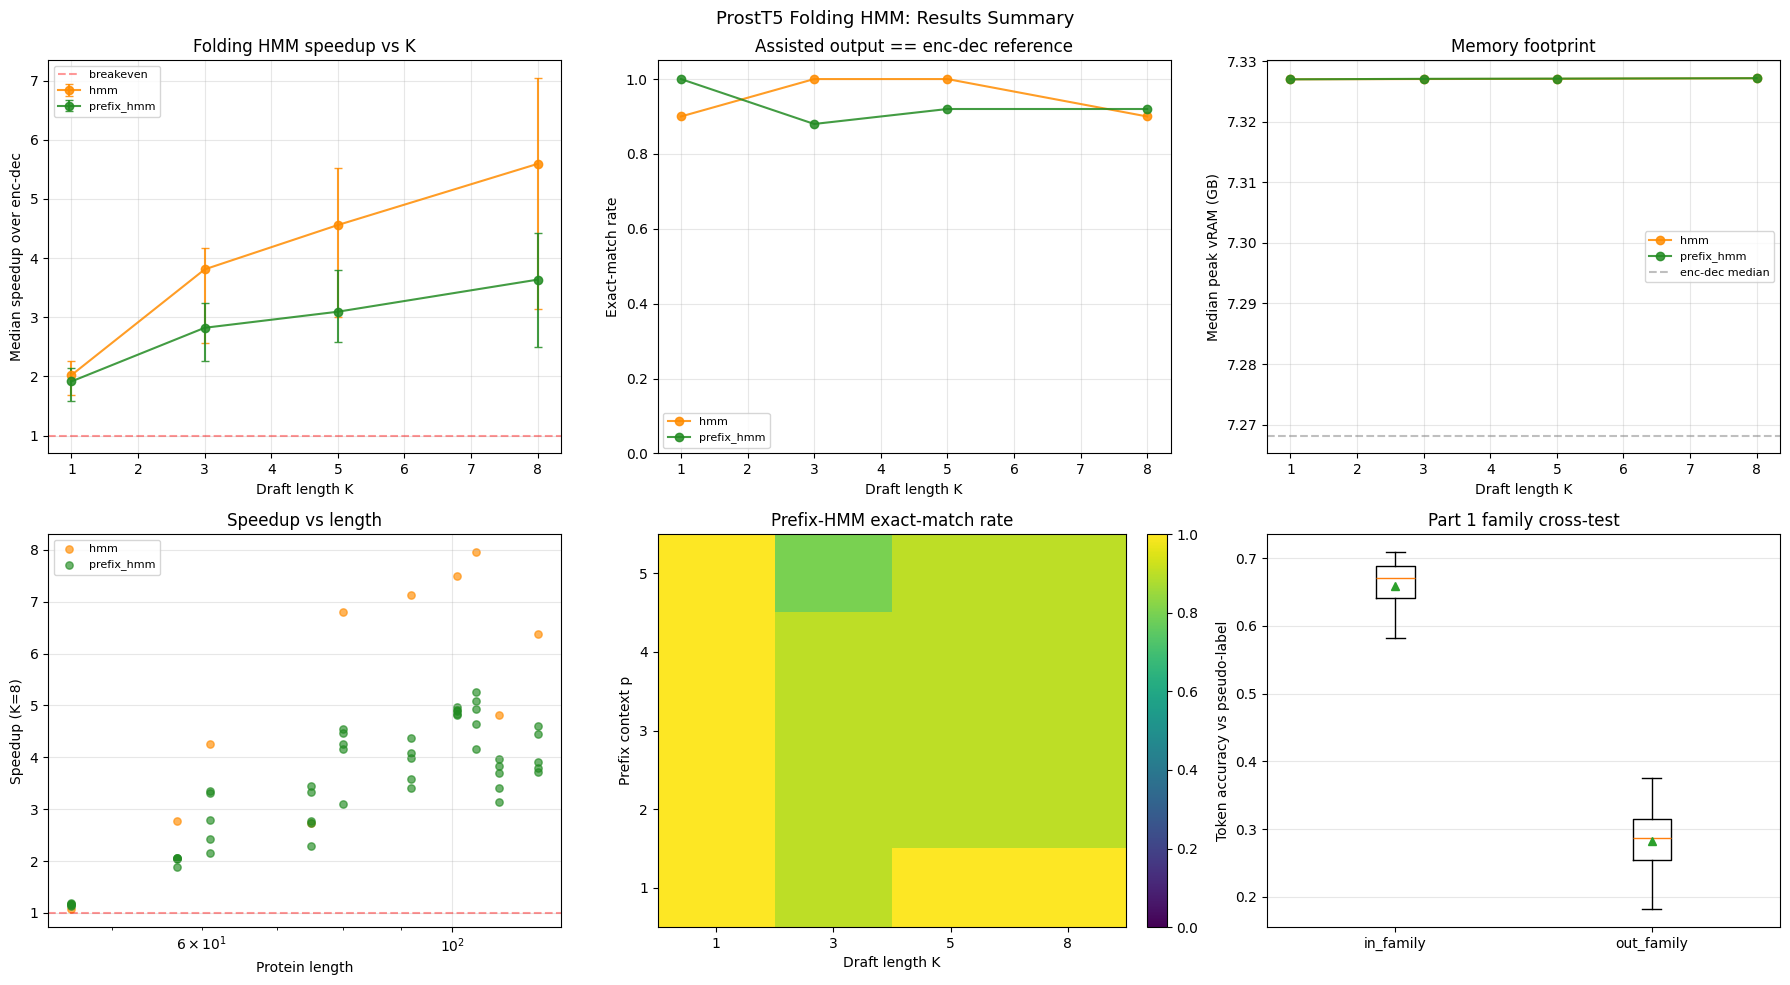

Saved plot to /content/Speculative-Decoding-ProstT5/prostT5/results/folding_hmm_results/folding_hmm_plots.png


In [31]:
#@title Plot folding HMM benchmark graphs. { display-mode: "form" }

import matplotlib.pyplot as plt

if len(plot_df) == 0:
    print("No folding HMM plot data available yet. Run the benchmark cells above first.")
else:
    colors = {"hmm": "darkorange", "prefix_hmm": "forestgreen"}
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # (0,0) Speedup vs K
    ax = axes[0, 0]
    for drafter in ["hmm", "prefix_hmm"]:
        sub = plot_df[plot_df["drafter"] == drafter]
        if len(sub) == 0:
            continue
        by_k = sub.groupby("K")["speedup"].median()
        q1 = sub.groupby("K")["speedup"].quantile(0.25)
        q3 = sub.groupby("K")["speedup"].quantile(0.75)
        ax.errorbar(
            by_k.index,
            by_k.values,
            yerr=[by_k.values - q1.values, q3.values - by_k.values],
            fmt="o-",
            label=drafter,
            color=colors[drafter],
            capsize=3,
            alpha=0.85,
        )
    ax.axhline(1.0, color="red", linestyle="--", alpha=0.4, label="breakeven")
    ax.set_xlabel("Draft length K")
    ax.set_ylabel("Median speedup over enc-dec")
    ax.set_title("Folding HMM speedup vs K")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (0,1) Exact-match rate vs K
    ax = axes[0, 1]
    for drafter in ["hmm", "prefix_hmm"]:
        sub = plot_df[plot_df["drafter"] == drafter]
        if len(sub) == 0:
            continue
        by_k = sub.groupby("K")["exact_match"].mean()
        ax.plot(by_k.index, by_k.values, "o-", label=drafter, color=colors[drafter], alpha=0.85)
    ax.set_xlabel("Draft length K")
    ax.set_ylabel("Exact-match rate")
    ax.set_ylim(0, 1.05)
    ax.set_title("Assisted output == enc-dec reference")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (0,2) Peak vRAM vs K
    ax = axes[0, 2]
    if "peak_vram_gb" in plot_df.columns:
        for drafter in ["hmm", "prefix_hmm"]:
            sub = plot_df[(plot_df["drafter"] == drafter) & plot_df["peak_vram_gb"].notna()]
            if len(sub) == 0:
                continue
            by_k = sub.groupby("K")["peak_vram_gb"].median()
            ax.plot(by_k.index, by_k.values, "o-", label=drafter, color=colors[drafter], alpha=0.85)
        if len(encdec_plot_df) > 0 and "peak_vram_gb" in encdec_plot_df.columns:
            enc_vram = encdec_plot_df["peak_vram_gb"].median()
            ax.axhline(enc_vram, color="gray", linestyle="--", alpha=0.5, label="enc-dec median")
        ax.set_ylabel("Median peak vRAM (GB)")
    ax.set_xlabel("Draft length K")
    ax.set_title("Memory footprint")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (1,0) Speedup vs protein length at best fixed K
    ax = axes[1, 0]
    best_k = plot_df.groupby("K")["speedup"].median().idxmax()
    for drafter in ["hmm", "prefix_hmm"]:
        sub = plot_df[(plot_df["drafter"] == drafter) & (plot_df["K"] == best_k)]
        if len(sub) == 0:
            continue
        ax.scatter(sub["length"], sub["speedup"], alpha=0.65, s=28, label=drafter, color=colors[drafter])
    ax.axhline(1.0, color="red", linestyle="--", alpha=0.4)
    ax.set_xscale("log")
    ax.set_xlabel("Protein length")
    ax.set_ylabel(f"Speedup (K={best_k})")
    ax.set_title("Speedup vs length")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (1,1) Prefix-aware p/K heatmap of exactness
    ax = axes[1, 1]
    if len(prefix_hmm_df) > 0:
        heat = prefix_hmm_df.pivot_table(index="p", columns="K", values="exact_match", aggfunc="mean")
        im = ax.imshow(heat.values, aspect="auto", origin="lower", vmin=0, vmax=1, cmap="viridis")
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels(heat.columns)
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(heat.index)
        ax.set_xlabel("Draft length K")
        ax.set_ylabel("Prefix context p")
        ax.set_title("Prefix-HMM exact-match rate")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, "No prefix-HMM rows", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()

    # (1,2) Family generalization in-family vs out-family
    ax = axes[1, 2]
    if len(family_cross_df) > 0 and {"relation", "token_acc"}.issubset(family_cross_df.columns):
        order = [x for x in ["in_family", "out_family"] if x in set(family_cross_df["relation"])]
        vals = [family_cross_df[family_cross_df["relation"] == rel]["token_acc"].dropna().values for rel in order]
        ax.boxplot(vals, labels=order, showmeans=True)
        ax.set_ylabel("Token accuracy vs pseudo-label")
        ax.set_title("Part 1 family cross-test")
        ax.grid(True, axis="y", alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No family cross-test rows", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()

    fig.suptitle("ProstT5 Folding HMM: Results Summary", fontsize=13)
    fig.tight_layout()
    plot_path = RESULTS_DIR / "folding_hmm_plots.png"
    fig.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved plot to {plot_path}")
